In [61]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor


perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])


<function matplotlib.pyplot.show(close=None, block=None)>

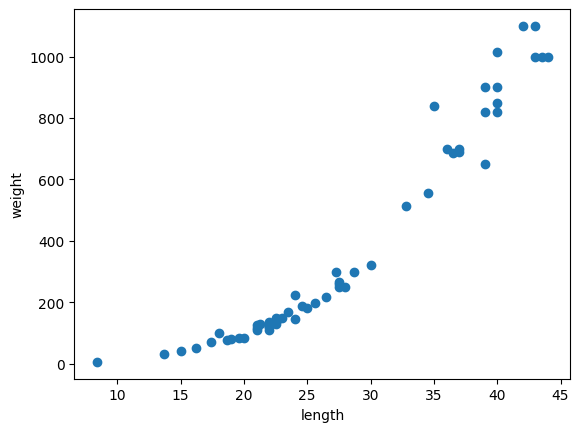

In [62]:
# 데이터 시각화 해보기
import matplotlib.pyplot as plt
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show

In [63]:
# 훈련 데이터 테스트 데이터 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [64]:
test_array = np.array([1,2,3,4])
print(test_array.shape)

(4,)


In [65]:
test_array = test_array.reshape(2,2)
print(test_array.shape)

(2, 2)


In [66]:
#데이터 전처리 => 모델이 원하는 입력 형태로 만들어주기 위해
train_input = train_input.reshape(-1, 1) # 형태(구조)를 변경해준다. 1차원 -> 2차원 행렬로
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


In [67]:
# 사이킷런 모델은 X(feature) 데이터로 2차원 배열을 입력받기 원함
model = KNeighborsRegressor()
model.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [68]:
# 예측
model.predict([[29]])

array([248.])

In [69]:
# 평가 : R^2 결정계수
model.score(test_input, test_target)

0.992809406101064

In [70]:
test_prediction = model.predict(test_input)

In [71]:
from sklearn.metrics import mean_absolute_error
test_prediction = model.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


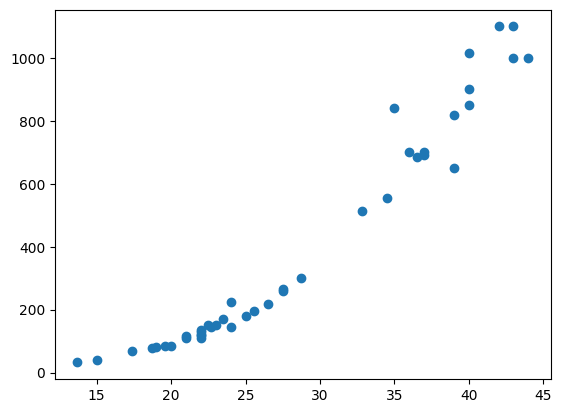

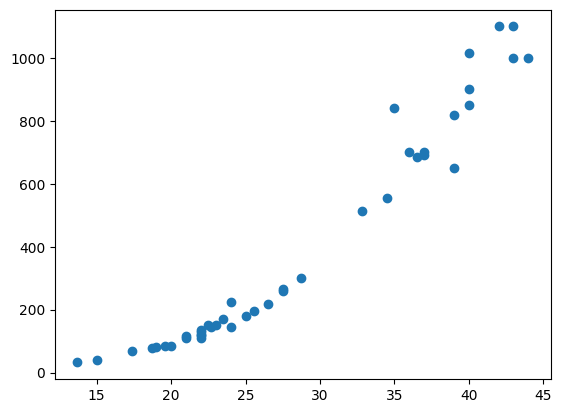

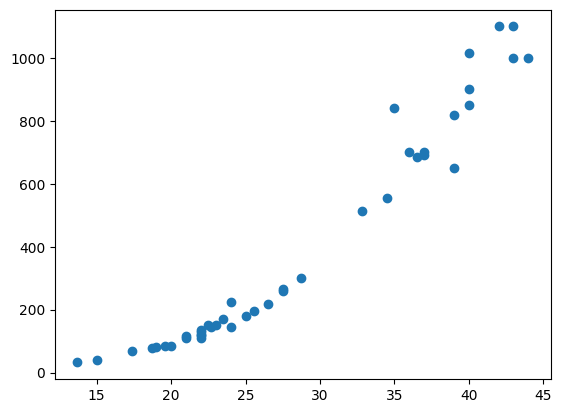

In [72]:
from matplotlib import pyplot as plt


model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)
for n in [1, 5, 10]:
    model.n_neighbors = n
    model.fit(train_input, train_target)
    prediction = model.predict(x)
    plt.scatter(train_input, train_target)
    plt.show()

# 선형 회귀

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
model = LinearRegression()
model.fit(train_input, train_target)

# 예측
print(model.predict([[100]]))
# 평가
model.score(test_input, test_target) # 결정계수 R^2

[3192.69585141]


0.824750312331356

In [75]:
# w 기울기
print("w : ", model.coef_)
# b 절편
print("b : ", model.intercept_)

w :  [39.01714496]
b :  -709.0186449535474


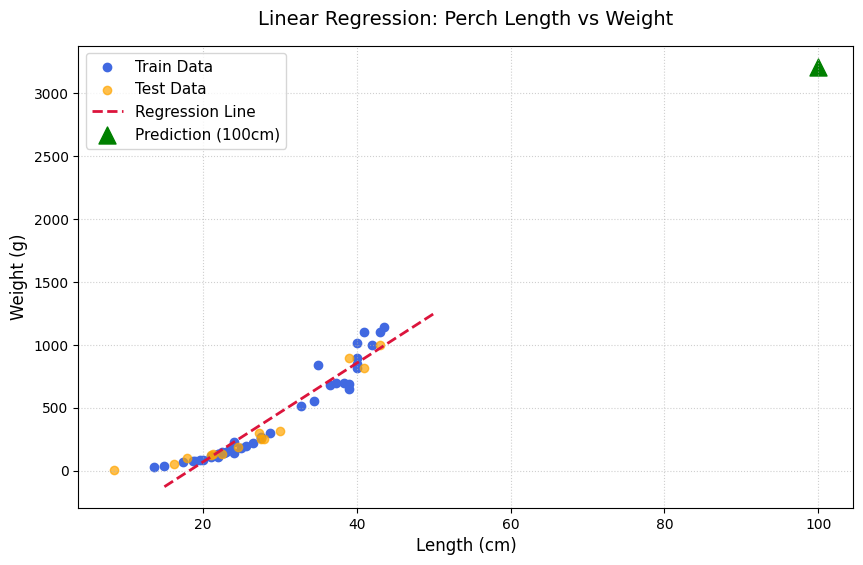

In [76]:
# 회귀선이 담긴 그래프를 그려줘
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. 데이터 준비 (노트북 내 제공된 데이터 기준)
perch_length = np.array([
    8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
    21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
    22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
    27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
    36.5, 37.3, 38.3, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0,
    41.0, 41.0, 42.0, 43.0, 43.0, 43.5
])
perch_weight = np.array([
    5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
    110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
    150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0,
    300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0,
    685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0,
    820.0, 1100.0, 1000.0, 1100.0, 1000.0, 1140.0
])

# 2. 훈련 세트와 테스트 세트로 나누기 및 2차원 배열 변환
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# 3. 선형 회귀 모델 훈련
model = LinearRegression()
model.fit(train_input, train_target)

# 4. 그래프 그리기
plt.figure(figsize=(10, 6))

# 훈련 데이터 산점도 (파란색 점)
plt.scatter(train_input, train_target, color='royalblue', label='Train Data')

# 테스트 데이터 산점도 (주황색 점)
plt.scatter(test_input, test_target, color='orange', alpha=0.7, label='Test Data')

# 회귀선 그리기 (x축 범위인 15부터 50까지의 직선 공식: y = w * x + b)
# 기울기(model.coef_)와 절편(model.intercept_) 활용
x_range = np.array([15, 50])
y_range = model.coef_ * x_range + model.intercept_
plt.plot(x_range, y_range, color='crimson', linestyle='--', linewidth=2, label='Regression Line')

# 100cm 농어 예측 값 표시 (노트북에 있던 예시)
pred_100 = model.predict([[100]])
plt.scatter(100, pred_100, color='green', marker='^', s=150, label='Prediction (100cm)')

# 그래프 스타일링
plt.title('Linear Regression: Perch Length vs Weight', fontsize=14, pad=15)
plt.xlabel('Length (cm)', fontsize=12)
plt.ylabel('Weight (g)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# 출력
plt.show()

In [77]:
print(model.score(test_input, test_target)) # 테스트 데이터 평가 -> 0.82
print(model.score(train_input, train_target)) # 훈련 데이터 평가 -> 0.93

0.8176197137234789
0.9300742522756699


In [78]:
# MSE : 평균 제곱 오차
from sklearn.metrics import mean_squared_error
mean_squared_error(test_target, test_prediction)
# 손실함수를 최소화 시키는 것이 선형 회귀의 학습이다. 

721.7385714285714

In [79]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.coef_)       # [39.02]  ← 길이 1cm 증가 = 무게 39g 증가
print(lr.intercept_)  # -709.02
print(lr.predict([[50]]))  # [1241.84]

print("train R²:", lr.score(train_input, train_target))  # 0.9398
print("test R²:",  lr.score(test_input, test_target))    # 0.8248

[39.28799507]
-716.2895356990005
[1248.11021799]
train R²: 0.9300742522756699
test R²: 0.8176197137234789


In [80]:
# x → [x², x]
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly  = np.column_stack((test_input ** 2, test_input))

lr2 = LinearRegression()
lr2.fit(train_poly, train_target)
print("train R²:", lr2.score(train_poly, train_target))  # 0.9707
print("test R²:",  lr2.score(test_poly, test_target))    # 0.9776  ← 선형보다 향상!

train R²: 0.9688989474493847
test R²: 0.9696251444888441


In [81]:
import io
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# 1. 제공해주신 데이터를 문자열로 직접 입력 (인증서 에러 원천 차단)
csv_data = """length, height, width
8.4 ,  2.11,  1.41
13.7,  3.53,  2.  
15. ,  3.82,  2.43
16.2,  4.59,  2.63
17.4,  4.59,  2.94
18. ,  5.22,  3.32
18.7,  5.2 ,  3.12
19. ,  5.64,  3.05
19.6,  5.14,  3.04
20. ,  5.08,  2.77
21. ,  5.69,  3.56
21. ,  5.92,  3.31
21. ,  5.69,  3.67
21.3,  6.38,  3.53
22. ,  6.11,  3.41
22. ,  5.64,  3.52
22. ,  6.11,  3.52
22. ,  5.88,  3.52
22. ,  5.52,  4.  
22.5,  5.86,  3.62
22.5,  6.79,  3.62
22.7,  5.95,  3.63
23. ,  5.22,  3.63
23.5,  6.28,  3.72
24. ,  7.29,  3.72
24. ,  6.38,  3.82
24.6,  6.73,  4.17
25. ,  6.44,  3.68
25.6,  6.56,  4.24
26.5,  7.17,  4.14
27.3,  8.32,  5.14
27.5,  7.17,  4.34
27.5,  7.05,  4.34
27.5,  7.28,  4.57
28. ,  7.82,  4.2 
28.7,  7.59,  4.64
30. ,  7.62,  4.77
32.8,  10.03,  6.02
34.5,  10.26,  6.39
35. ,  11.49,  7.8 
36.5,  10.88,  6.86
36. ,  10.61,  6.74
37. ,  10.84,  6.26
37. ,  10.57,  6.37
39. ,  11.14,  7.49
39. ,  11.14,  6.  
39. ,  12.43,  7.35
40. ,  11.93,  7.11
40. ,  11.73,  7.22
40. ,  12.38,  7.46
40. ,  11.14,  6.63
42. ,  12.8 ,  6.87
43. ,  11.93,  7.28
43. ,  12.51,  7.42
43.5,  12.6 ,  8.14
44. ,  12.49,  7.6"""

# 판다스로 문자열 데이터 읽기
perch_full = pd.read_csv(io.StringIO(csv_data))

# 농어의 무게 데이터 (타깃)
perch_weight = [
    5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
    115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
    150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
    218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
    556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
    850.0, 900.0, 1015.0, 995.0, 1100.0, 1000.0, 1100.0, 1000.0, 1000.0
]

# 2. 데이터 분할
train_i, test_i, train_t, test_t = train_test_split(perch_full, perch_weight, random_state=42)

# 3. 다항 특성 변환기 생성 (기존 3개 특성을 제곱, 교차 곱하여 9개로 확장)
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_i)

train_poly = poly.transform(train_i)
test_poly  = poly.transform(test_i)   # test 세트에는 오직 transform만 수행

# 4. 최종 결과 출력
print("훈련 세트 크기:", train_poly.shape)  # (42, 9)
print("테스트 세트 크기:", test_poly.shape)  # (14, 9)

훈련 세트 크기: (42, 9)
테스트 세트 크기: (14, 9)


In [82]:
poly5 = PolynomialFeatures(degree=5, include_bias=False)
poly5.fit(train_i)
train_poly5 = poly5.transform(train_i)
test_poly5  = poly5.transform(test_i)
print(train_poly5.shape)  # (42, 55)

lr.fit(train_poly5, train_t)
print("train R²:", lr.score(train_poly5, train_t))  # 1.0000  ← 과적합!
print("test R²:",  lr.score(test_poly5, test_t))    # -144.4  ← 폭망!

(42, 55)
train R²: 0.9999999999997232
test R²: -126.42596163434796


In [83]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ss = StandardScaler()
train_scaled = ss.fit_transform(train_poly5)
test_scaled  = ss.transform(test_poly5)

ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_t)
print("train R²:", ridge.score(train_scaled, train_t))  # 0.9904
print("test R²:",  ridge.score(test_scaled, test_t))    # 0.9828  ← -144에서 회복!

train R²: 0.9903815817570367
test R²: 0.9579526213930312


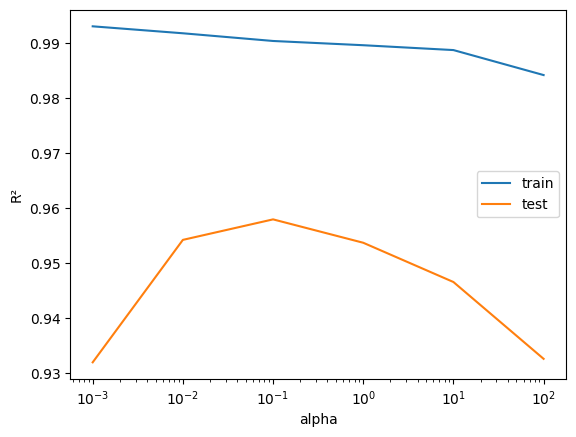

In [84]:
import matplotlib.pyplot as plt

train_score, test_score = [], []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_t)
    train_score.append(ridge.score(train_scaled, train_t))
    test_score.append(ridge.score(test_scaled, test_t))

plt.plot(alpha_list, train_score, label='train')
plt.plot(alpha_list, test_score,  label='test')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R²')
plt.legend()
plt.show()

In [85]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(train_scaled, train_t)
print("train R²:", lasso.score(train_scaled, train_t))  # 0.9898
print("test R²:",  lasso.score(test_scaled, test_t))    # 0.9801
print("0인 계수 수:", np.sum(lasso.coef_ == 0))         # 40~47 (자동 특성 선택)

train R²: 0.9898116789062786
test R²: 0.9548451421951453
0인 계수 수: 47
